In [1]:
import pysam
import pandas as pd
import numpy as np
import os
import pygenomeviz
from Bio.Seq import Seq
from Bio import SeqIO
import re
from pygenomeviz import GenomeViz
from scipy.spatial import distance

In [2]:
from typing import List, Optional
from Bio import Phylo

def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)
    
def tip_order_from_nexus_biopython(
    nexus_path: str,
    tree_label: Optional[str] = None
) -> List[str]:
    """
    Returns the left-to-right tip (sample) order from a NEXUS file using Biopython.
    If `tree_label` is given, picks that named tree; else the first tree in the file.
    """
    trees = list(Phylo.parse(nexus_path, "nexus"))
    if not trees:
        raise ValueError("No trees found in NEXUS file.")

    if tree_label is not None:
        matches = [t for t in trees if (t.name or "") == tree_label]
        if not matches:
            raise ValueError(f"Tree labeled '{tree_label}' not found.")
        tree = matches[0]
    else:
        tree = trees[0]

    tip_order = [clade.name for clade in tree.find_clades(order="preorder") if clade.is_terminal()]
    return tip_order

In [3]:
phylogeneticOrder=()
tips_bio = tip_order_from_nexus_biopython("/LeeLab/HPRC/chromosomeY/Information/phylogeny/142males_HGSVC_HPRC_CEPH_241125_150M-FOR_SHARING.nex")         # first tree

for sample in tips_bio:
    phylogeneticOrder = add_feature(phylogeneticOrder, sample)
   
print(phylogeneticOrder)
print(len(phylogeneticOrder))

haplogroups={}
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')#
phylDF['GoodSampleNames']=[x.split("/")[1] if '/' in x else x for x in phylDF['sample']]
phylDF.set_index("GoodSampleNames", inplace=True)

for sample in phylogeneticOrder:
    if sample in phylDF.index:
        haplogroups[sample]=phylDF.at[sample,'haplogroup_ISOGG_v15.73']
    else:
        continue

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

print(len(haplogroups))

('HG02984', 'HG01890', 'HG02647', 'HG02666', 'HG02668', 'HG03225', 'NA19043', 'NA19384', 'HG005', 'NA18952', 'NA18983', 'HG02572', 'HG03248', 'HG03098', 'HG03050', 'NA19239', 'HG01074', 'HG01109', 'HG01106', 'NA19331', 'HG01252', 'HG01457', 'HG03065', 'HG02717', 'HG03471', 'HG02011', 'HG03371', 'HG02486', 'HG02965', 'HG03139', 'NA19443', 'NA19317', 'NA19347', 'NA20346', 'HG02145', 'HG02258', 'HG02953', 'HG03130', 'HG03521', 'HG02554', 'NA18879', 'HG03209', 'NA18522', 'NA19700', 'HG02055', 'NA19705', 'NA18612', 'NA18620', 'HG04157', 'NA18989', 'NA18971', 'NA18974', 'HG02040', 'NA20870', 'HG03710', 'HG01099', 'HG03579', 'NA21093', 'HG04187', 'HG03009', 'HG03942', 'HG01167', 'HG00140', 'HG00321', 'NA20905', 'HG02492', 'HG02735', 'NA20805', 'NA20809', 'HG01255', 'HG01258', 'HG01433', 'HG003', 'HG002', 'HG03688', 'HG04199', 'HG01192', 'HG01530', 'HG03742', 'NA18608', 'NA18747', 'HG00280', 'HG00329', 'HG00290', 'HG00358', 'HG02015', 'HG02083', 'HG02514', 'HG02074', 'NA18534', 'HG02027', 'HG0

In [4]:
goodTSPYSamples=[]
with open('/LeeLab/HPRC/chromosomeY/QC/LocationFiles/TSPY_QC_File.txt','r') as inFile:
    for line in inFile:
        goodTSPYSamples.append(line.strip())

print(len(goodTSPYSamples))

110


## Read in Amino Acid Alignment

In [5]:
from Bio import SeqIO

groups={}
sequences={}
groupSamples={}
fasta_sequences = SeqIO.parse(open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/PulledSequences/StitchedExons/HPRC-HGSVC3-CEPH_v2_TSPY1.Exons.translated_withGaps.afa'),'fasta')
for fasta in fasta_sequences:
    name, sequence = fasta.id, str(fasta.seq)
    if 'NA12883' in name or 'NA12884' in name:
        continue
    else:
        sequences[name.split("_C")[0].split("_+")[0]]=sequence
        if sequence in groups:
            groups[sequence].append(name.split("_C")[0].split("_+")[0])
            groupSamples[sequence].append(name.split("_chrY")[0])
        else:
            groups[sequence]=[name.split("_C")[0].split("_+")[0]]
            groupSamples[sequence]=[name.split("_chrY")[0]]

groupTotals=[]
for group, items in groups.items():
    groupTotals.append([group, len(items)])
groupTotalDF = pd.DataFrame(data=groupTotals).sort_values(by=[1], ascending=False)

groupNumber=1
groupNumberOrderings=[]
groupNumberings={}
for row in groupTotalDF.index:
    groupNumberings[groupTotalDF.at[row,0]]='ESG:'+str(groupNumber)
    groupNumberOrderings.append('ESG:'+str(groupNumber))
    groupNumber+=1

In [6]:
groupSamples2= {}
for sequence, sampleList in groupSamples.items():
    groupSamples2[groupNumberings[sequence]] = len(set(sampleList))

In [7]:
groupTotalDF['GroupNumbers'] = [groupNumberings[x] for x in groupTotalDF[0]]

In [8]:
print(len(groups))

131


In [9]:
groupList=[]
for sequence in groups.keys():
    tempList=[groupNumberings[sequence]]
    for x in sequence:
        tempList.append(x)
    groupList.append(tempList)
groupDF = pd.DataFrame(data=groupList).set_index(0)

In [10]:
comparisonDF = pd.DataFrame(0.0,index=groupNumberOrderings, columns=groupNumberOrderings)
for row in comparisonDF.index:
    for column in comparisonDF.columns:
        if row == column:
            continue
        else:
            comparisonDF.at[row,column] = distance.hamming([x for x in groupDF.loc[row]], [x for x in groupDF.loc[column]])

In [11]:
pairings={x:{'distance':'temp', 'matches':[]} for x in comparisonDF.index}
for group in comparisonDF.index:
    tempDF = comparisonDF[[x for x in comparisonDF.columns if x != group]].copy()
    minimum = min(tempDF.loc[group])
    if minimum > .05:
        continue
    else:
        for column in comparisonDF.columns:
            if comparisonDF.at[group, column] == minimum and group!=column:
                pairings[group]['matches'].append(column)
            else:
                continue
        pairings[group]['distance']=minimum

In [11]:
import networkx as nx

def build_match_graph(node_names, links, node_sizes=None, undirected=True, keep_unknown=False):
    """
    Build a networkx graph from node list and link dictionary.
    """
    node_set = set(node_names)
    G = nx.Graph() if undirected else nx.DiGraph()
    G.add_nodes_from(node_names)

    if node_sizes:
        for n, s in node_sizes.items():
            if n in G:
                G.nodes[n]["size"] = np.log(s)+1
                G.nodes[n]["realsize"] = s

    for src, payload in links.items():
        if src not in node_set and not keep_unknown:
            continue

        matches = payload.get("matches", [])
        src_distance = payload.get("distance", None)

        if keep_unknown and src not in G:
            G.add_node(src)

        for dst in matches:
            if dst == src:
                continue
            if not keep_unknown and dst not in node_set:
                continue
            if keep_unknown and dst not in G:
                G.add_node(dst)

            G.add_edge(src, dst, match=True, distance_from_src=src_distance)

    return G

In [12]:
groupTotalDict={groupNumberings[x]:y for x,y in zip(groupTotalDF[0], groupTotalDF[1])}
G = build_match_graph(groupNumberOrderings, pairings, node_sizes=groupTotalDict)

In [13]:
groupTotalDF['PSC'] = ['TRUE' if 'X' in x.upper() else "FALSE" for x in list(groupTotalDF[0])]
groupTotalDF2 = groupTotalDF.set_index("GroupNumbers").copy()

In [14]:
import pyvis.network as net
nt = net.Network(notebook=True)
nt.from_nx(G)
for node in nt.nodes:
    node_id = node['id']
    node['size'] = G.nodes[node_id].get('size', 1) 
    node['samplesize'] = groupSamples2[node_id]
    if groupTotalDF2.at[node_id, 'PSC'] =='TRUE':
         node['color'] = G.nodes[node_id].get('color', 'black')
    else:
        if groupSamples2[node_id] == 1:
            node['color'] = G.nodes[node_id].get('color', 'red') 
        else:
            node['color'] = G.nodes[node_id].get('color', 'lightblue') 
    
nt.show("network.html")

network.html


## Start merging Nodes

In [15]:
import networkx as nx
from collections import defaultdict
from typing import Callable, Hashable, Tuple, Dict, List, Optional, Mapping

def prune_leaves_with_logging(
    G: nx.Graph | nx.DiGraph | nx.MultiGraph | nx.MultiDiGraph,
    iterative: bool = True,
    attr_merge: Optional[Callable[[nx.Graph, Hashable, Hashable], None]] = None,
    *,
    group_map: Optional[Mapping[Hashable, int]] = None,   
    size_attr: str = "realsize",                         
) -> Tuple[nx.Graph, Dict[Hashable, Hashable], Dict[Hashable, List[Hashable]]]:

    H = G.copy()
    merged_into_immediate: Dict[Hashable, Hashable] = {}   
    absorbed_by_immediate: Dict[Hashable, List[Hashable]] = defaultdict(list)
    merge_history: List[Tuple[Hashable, Hashable]] = []    

    def _undirected_view():
        return H.to_undirected(as_view=True) if hasattr(H, "to_undirected") else H

    def _decide_merge(u, U) -> Optional[Tuple[Hashable, Hashable]]:
        if u not in U:
            return None

        deg_u = U.degree(u)

        if deg_u == 1:
            v = next(iter(U.neighbors(u)))
            if U.degree(v) > 1:
                return (u, v)

        group_is_one = (group_map is not None and group_map.get(u) == 1)
        size_u = U.nodes[u].get(size_attr, None)
        size_is_one = (size_u == 1)

        if group_is_one or size_is_one:
            if deg_u == 0:
                return None
            neighbor_sizes = {nbr: U.nodes[nbr].get(size_attr, 0) for nbr in U.neighbors(u)}
            if not neighbor_sizes:
                return None
            v = max(neighbor_sizes, key=neighbor_sizes.get)
            if v != u:
                return (u, v)

        return None

    while True:
        U = _undirected_view()

        firstRoundMergers: List[Hashable] = [u for u in H if U.degree(u) == 1]
        to_remove: List[Tuple[Hashable, Hashable]] = []
        slated_us: set[Hashable] = set()

        for u in firstRoundMergers:
            m = _decide_merge(u, U)
            if m is not None:
                uu, vv = m
                if uu not in slated_us:
                    to_remove.append((uu, vv))
                    slated_us.add(uu)

        for u in H:
            if u in slated_us or u in firstRoundMergers:
                continue
            m = _decide_merge(u, U)
            if m is not None:
                uu, vv = m
                if uu not in slated_us:
                    to_remove.append((uu, vv))
                    slated_us.add(uu)

        if not to_remove:
            break

        for u, v in to_remove:
            if u not in H or v not in H or u == v:
                continue
            if attr_merge is not None:
                attr_merge(H, u, v)
            merged_into_immediate[u] = v
            absorbed_by_immediate[v].append(u)
            merge_history.append((u, v))  
            H.remove_node(u)

        if not iterative:
            break


    parent: Dict[Hashable, Hashable] = {}
    for n in G.nodes():
        parent[n] = n
    for u, v in merge_history:
        parent[u] = v

    def find(x: Hashable) -> Hashable:
        px = parent.get(x, x)
        if px != x:
            parent[x] = find(px)
        return parent[x]

    for n in list(parent.keys()):
        parent[n] = find(n)

    merged_into_final: Dict[Hashable, Hashable] = {}
    for u, v in merge_history:
        rep = find(u)
        if rep != u:
            merged_into_final[u] = rep

    absorbed_by_final: Dict[Hashable, List[Hashable]] = defaultdict(list)
    for u, rep in merged_into_final.items():
        absorbed_by_final[rep].append(u)

    H.graph["merge_history"] = merge_history
    H.graph["merged_into_immediate"] = dict(merged_into_immediate)
    H.graph["absorbed_by_immediate"] = dict(absorbed_by_immediate)
    H.graph["merged_into_final"] = dict(merged_into_final)
    H.graph["absorbed_by_final"] = dict(absorbed_by_final)

    return H, merged_into_final, dict(absorbed_by_final)

In [16]:
def sum_size_and_track_sources(H: nx.Graph, u, v):
    su = H.nodes[u].get("realsize", 0)
    sv = H.nodes[v].get("realsize", 0)
    H.nodes[v]["realsize"] = sv + su
    H.nodes[v].setdefault("merged_from", [])
    H.nodes[v]["merged_from"].append(u)

In [17]:
def add_sizes_attr_merge(H: nx.Graph, u, v):
    su = H.nodes[u].get("realsize", 0)
    sv = H.nodes[v].get("realsize", 0)
    H.nodes[v]["realsize"] = su + sv

H, merged_into, absorbed_by = prune_leaves_with_logging(
    G,
    iterative=True,                
    attr_merge=add_sizes_attr_merge,
    group_map=groupSamples2,            
    size_attr="realsize",      
)

In [15]:
import networkx as nx
import colorsys
from typing import Hashable, Iterable
import random

def assign_colors_propagating_from_topN(
    G: nx.Graph | nx.DiGraph | nx.MultiGraph | nx.MultiDiGraph,
    *,
    num_hubs: int = 9,   
    size_attr: str = "realsize",
    base_color_names: Iterable[str] = ("green", "blue", "orange", "red", "yellow", "purple", "brown", "pink", "cyan"),
    default_unreachable_hex: str = "#bfbfbf",
    max_rounds: int = 10,
):
    """
    1) Pick the top `num_hubs` nodes by `size_attr` as hubs; assign distinct base colors
       using the first `num_hubs` entries from `base_color_names` (must be unique names).
    2) Propagate colors outward. Nodes color themselves once they have >=1 colored neighbor:
       - If all colored neighbors trace back to a single root hub -> unique hue-jitter of that hub's base.
       - If multiple roots influence the node -> random-weighted (deterministic) mix of neighbors' current colors.
    3) Nodes that never connect to any colored neighbor stay gray.

    Returns (node_to_hex, hubs)
    """
    NAMED = {
        "yellow": (252, 186, 3),
        "blue":   ( 31, 120, 180),
        "orange": (255, 127,   0),
        "red":    (227,  26,  28),
        "green":  ( 51, 160,  44),
        "purple": (106,  61, 154),
        "brown":  (123,  63,   0),
        "pink":  (250, 0, 221),
        "cyan":(0, 224, 222)
    }

    def to_hex(rgb):
        r, g, b = (max(0, min(255, int(round(x)))) for x in rgb)
        return f"#{r:02x}{g:02x}{b:02x}"

    def hex_to_rgb(hx: str):
        hx = hx.lstrip("#")
        return tuple(int(hx[i:i+2], 16) for i in (0, 2, 4))

    def rgb255_to_hsv(rgb):
        r, g, b = (c/255.0 for c in rgb)
        return colorsys.rgb_to_hsv(r, g, b) 

    def hsv_to_rgb255(h, s, v):
        r, g, b = colorsys.hsv_to_rgb(h, s, v)
        return int(round(r*255)), int(round(g*255)), int(round(b*255))

    def gamma_mix_rgbs(rgbs, weights):
        # keep mixtures vibrant
        gamma = 2.2
        rs = gs = bs = 0.0
        for w, (r, g, b) in zip(weights, rgbs):
            rs += w * ((r/255.0) ** gamma)
            gs += w * ((g/255.0) ** gamma)
            bs += w * ((b/255.0) ** gamma)
        r = int(round((rs ** (1/gamma)) * 255))
        g = int(round((gs ** (1/gamma)) * 255))
        b = int(round((bs ** (1/gamma)) * 255))
        return (r, g, b)

    def size_of(n):
        v = G.nodes[n].get(size_attr, float("-inf"))
        try:
            return float(v)
        except Exception:
            return float("-inf")

    nodes_sorted = sorted(G.nodes(), key=lambda n: (size_of(n), str(n)), reverse=True)

    k = min(num_hubs, len(nodes_sorted))
    hubs = nodes_sorted[:k]

    base_names = list(base_color_names)[:k]
    if len(set(base_names)) != len(base_names):
        raise ValueError("Base colors for hubs must be unique (duplicates found).")
    for name in base_names:
        if name not in NAMED:
            raise ValueError(f"Unknown base color name: {name}")

    hub_to_colorname = {h: base_names[i] for i, h in enumerate(hubs)}
    hub_to_rgb = {h: NAMED[hub_to_colorname[h]] for h in hubs}
    hub_to_hsv = {h: rgb255_to_hsv(hub_to_rgb[h]) for h in hubs}

    U = G.to_undirected(as_view=True) if hasattr(G, "to_undirected") else G

    node_to_hex: dict[Hashable, str] = {}

    used_hex_per_hub: dict[Hashable, set[str]] = {}
    for h in hubs:
        hx = to_hex(hub_to_rgb[h])
        node_to_hex[h] = hx
        used_hex_per_hub[h] = {hx}
        G.nodes[h]["color_hex"] = hx
        G.nodes[h]["color_kind"] = "hub"
        G.nodes[h]["color_sources"] = [h]
        G.nodes[h]["color_roots"] = [h]
        G.nodes[h]["color_name"] = hub_to_colorname[h]

    for n in G.nodes():
        if n in hubs:
            continue
        for kattr in ("color_hex", "color_kind", "color_sources", "color_roots", "color_name"):
            G.nodes[n].pop(kattr, None)

    def deterministic_weights(node_key: tuple, n: int) -> list[float]:
        seed = (hash(node_key) ^ 0x9e3779b97f4a7c15) & 0xffffffffffff
        rnd = random.Random(seed)
        raw = [rnd.random() + 1e-9 for _ in range(n)]
        s = sum(raw)
        return [x/s for x in raw]

    def unique_hue_variant_for_hub(hub: Hashable, node: Hashable) -> str:
        h0, s0, v0 = hub_to_hsv[hub]
        used = used_hex_per_hub[hub]
        attempt = 0
        while True:
            rnd = random.Random((hash((str(hub), str(node), attempt)) & 0xffffffffffff))
            dh = rnd.uniform(-0.10, 0.10)  
            s  = min(1.0, max(0.55, 0.7 * s0 + 0.3 * rnd.uniform(0.7, 1.0)))
            v  = min(1.0, max(0.60, 0.7 * v0 + 0.3 * rnd.uniform(0.75, 1.0)))
            h  = (h0 + dh) % 1.0
            rgb = hsv_to_rgb255(h, s, v)
            hx  = to_hex(rgb)
            if hx not in used:
                used.add(hx)
                return hx
            attempt += 1
            if attempt > 256:
                dh = rnd.uniform(-0.25, 0.25)
                h  = (h0 + dh) % 1.0
                rgb = hsv_to_rgb255(h, s, v)
                hx  = to_hex(rgb)
                if hx not in used:
                    used.add(hx)
                    return hx

    progress = True
    rounds = 0
    while progress and rounds < max_rounds:
        progress = False
        rounds += 1

        for n in G.nodes():
            if "color_hex" in G.nodes[n]:
                continue  

            colored = [nbr for nbr in U.neighbors(n) if G.nodes[nbr].get("color_hex")]
            if not colored:
                continue

            root_union = set()
            for nbr in colored:
                root_union.update(G.nodes[nbr].get("color_roots", []))

            if len(root_union) == 1:
                root_hub = next(iter(root_union))
                hx_new = unique_hue_variant_for_hub(root_hub, n)
                G.nodes[n]["color_hex"] = hx_new
                G.nodes[n]["color_kind"] = "propagated_single_root"
                G.nodes[n]["color_sources"] = sorted(map(str, colored))
                G.nodes[n]["color_roots"] = [root_hub]
                node_to_hex[n] = hx_new
                progress = True
            else:
                colored_sorted = sorted(colored, key=lambda x: str(x))
                weights = deterministic_weights(("mix", str(n), tuple(map(str, colored_sorted))), len(colored_sorted))
                rgbs = [hex_to_rgb(G.nodes[c]["color_hex"]) for c in colored_sorted]
                mix_rgb = gamma_mix_rgbs(rgbs, weights)
                hx_new = to_hex(mix_rgb)

                G.nodes[n]["color_hex"] = hx_new
                G.nodes[n]["color_kind"] = "propagated_multi_root"
                G.nodes[n]["color_sources"] = list(map(str, colored_sorted))
                G.nodes[n]["color_roots"] = sorted(root_union, key=str)
                node_to_hex[n] = hx_new
                progress = True

    for n in G.nodes():
        if "color_hex" not in G.nodes[n]:
            G.nodes[n]["color_hex"] = default_unreachable_hex
            G.nodes[n]["color_kind"] = "none"
            G.nodes[n]["color_sources"] = []
            G.nodes[n]["color_roots"] = []
            node_to_hex[n] = default_unreachable_hex

    return node_to_hex, hubs

In [19]:
#ColorDictionary = assign_colors_propagating_from_topN(H)

In [20]:
import json
#with open('/LeeLab/HPRC/chromosomeY/Information/TSPY_Network_Node_Colors.json', 'w') as fp:
#    json.dump(ColorDictionary, fp)

with open('/LeeLab/HPRC/chromosomeY/Information/TSPY_Network_Node_Colors.json', 'r') as file:
    ColorDictionary = json.load(file)

In [22]:
import pyvis.network as net
nt = net.Network(notebook=True)
nt.from_nx(H)
for node in nt.nodes:
    node_id = node['id']
    node['size'] = H.nodes[node_id].get('size', 1)  # default 10 if no size set
    node['samplesize'] = groupSamples2[node_id]
    node['color'] = ColorDictionary[0][node_id]
    
nt.show("network_pruned.html")

network_pruned.html


## Get the colors in proper order

In [12]:
absorbed_by2={}
for key, values in absorbed_by.items():
    if groupTotalDF2.at[key,'PSC']=='FALSE':
        absorbed_by2[key]=[ColorDictionary[0][key],'white']
    else:
        absorbed_by2[key]=[ColorDictionary[0][key],'black']

        
    for item in values:
        if groupTotalDF2.at[item,'PSC']=='FALSE':
            absorbed_by2[item]=[ColorDictionary[0][key],'white']
        else:
            absorbed_by2[item]=[ColorDictionary[0][key],'black']


for key, color in ColorDictionary[0].items():
    if key in absorbed_by2.keys():
        continue
    else:
        if groupTotalDF2.at[key,'PSC']=='FALSE':
            absorbed_by2[key]=[ColorDictionary[0][key],'white']
        else:
            absorbed_by2[key]=[ColorDictionary[0][key],'black']

NameError: name 'absorbed_by' is not defined

In [13]:
coordinateColorings={}
for coordinate, sequence in sequences.items():
    coordinateColorings[coordinate] = absorbed_by2[groupNumberings[sequence]]

KeyError: 'ESG:71'

In [14]:
#with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Network_Node_Colors_IDs.json', 'w') as fp:
#    json.dump(ColorDictionary, fp)

import json
with open('/LeeLab/HPRC/chromosomeY/Data/AmpliconicGenes/TSPY_Plus_Flanking/TSPY_Network_Node_Colors_IDs.json', 'r') as file:
    ColorDictionary = json.load(file)

## Read in HMMER results to include the highly divergent 'black' TSPY copies

In [16]:
def addInformation(df):
    df2 =df.copy()
    df2['DistanceBetween']=0
    flag=0
    for row in df2.index:
        if flag==0:
            previousEnd = int(df2.at[row,'6'])
            flag+=1
        else:
            df2.at[row, 'DistanceBetween'] = df2.at[row,'5']-previousEnd
            previousEnd = int(df2.at[row,'6'])

    df2['NewStart'] = 0
    df2['NewEnd'] = 0
    baseStart = min(df2['5'])-1
    flag=0
    for row in df2.index:
        if flag==0:
            df2.at[row,'NewStart'] = df2.at[row,'5']-baseStart
            df2.at[row, 'NewEnd'] = df2.at[row,'6']-baseStart
            flag+=1
        else:
            if df2.at[row, 'DistanceBetween']<100000:
                df2.at[row,'NewStart'] = df2.at[row,'5']-baseStart
                df2.at[row, 'NewEnd'] = df2.at[row,'6']-baseStart
            else:
                baseStart+= (df2.at[row, 'DistanceBetween']-100000)
                df2.at[row,'NewStart'] = df2.at[row,'5']-baseStart
                df2.at[row, 'NewEnd'] = df2.at[row,'6']-baseStart

    return(df2)

In [17]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [18]:
directory = '/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/tspyhmmerFilter/'
samplestoVisualize=[]
genome_list = []
for file in os.listdir(directory):
    if '.csv' in str(file) and 'RFC' not in str(file) and 'RFG' not in str(file):
        print(file)
        sampleName = file.split(".")[0]

        if sampleName in goodTSPYSamples:
            samplestoVisualize.append(sampleName)
            df = pd.read_csv(directory+file)
            if 'HG03456' in file:
                contigs = ['HG03456_chrY_1', 'HG03456_chrY_2']
                for contig in contigs:
                    
                    df2 = df[df['1']==contig].copy()
                    df3 = addInformation(df2)
                    start=1
                    features2=()
                    for row in df3.index:
                        length = (df3.at[row,'NewEnd'] - df3.at[row,'NewStart'])+1
                        features2 = add_feature(features2, (df3.at[row,'NewStart'], df3.at[row,'NewEnd'], df3.at[row,'7'], df3.at[row,'2'], contig,df3.at[row,'5'],df3.at[row,'6']))
                        
                    totalsize= (max(df3['NewEnd'])+1)
                    genome_list.append(dict(name=sampleName, size=totalsize, features=features2))

            else:
                contig = sampleName+"_chrY"
                samplestoVisualize.append(sampleName)
                df2 = df[df['1']==contig].copy()
                df3 = addInformation(df2)
                start=1
                features2=()
                for row in df3.index:
                    length = (df3.at[row,'NewEnd'] - df3.at[row,'NewStart'])+1
                    features2 = add_feature(features2, (df3.at[row,'NewStart'], df3.at[row,'NewEnd'], df3.at[row,'7'], df3.at[row,'2'], contig,df3.at[row,'5'],df3.at[row,'6']))
                    
                totalsize= (max(df3['NewEnd'])+1)
                genome_list.append(dict(name=sampleName, size=totalsize, features=features2))

HG01928.hmmerTSPY.csv
HG02392.hmmerTSPY.csv
HG00642.hmmerTSPY.csv
HG02984.hmmerTSPY.csv
NA19700.hmmerTSPY.csv
NA19650.hmmerTSPY.csv
NA18983.hmmerTSPY.csv
HG00738.hmmerTSPY.csv
HG03710.hmmerTSPY.csv
NA18879.hmmerTSPY.csv
HG02486.hmmerTSPY.csv
HG03017.hmmerTSPY.csv
NA12884.hmmerTSPY.csv
HG02027.hmmerTSPY.csv
NA20805.hmmerTSPY.csv
HG00126.hmmerTSPY.csv
HG003.hmmerTSPY.csv
HG02129.hmmerTSPY.csv
HG00280.hmmerTSPY.csv
HG01192.hmmerTSPY.csv
HG00621.hmmerTSPY.csv
HG02040.hmmerTSPY.csv
HG00290.hmmerTSPY.csv
NA12877.hmmerTSPY.csv
HG01106.hmmerTSPY.csv
HG04204.hmmerTSPY.csv
HG03130.hmmerTSPY.csv
NA18522.hmmerTSPY.csv
HG01530.hmmerTSPY.csv
NA18747.hmmerTSPY.csv
NA18974.hmmerTSPY.csv
HG03456.hmmerTSPY.csv
HG00706.hmmerTSPY.csv
NA19331.hmmerTSPY.csv
NA12883.hmmerTSPY.csv
HG01243.hmmerTSPY.csv
HG02391.hmmerTSPY.csv
HG03654.hmmerTSPY.csv
HG02492.hmmerTSPY.csv
HG03248.hmmerTSPY.csv
HG00096.hmmerTSPY.csv
HG00731.hmmerTSPY.csv
HG00658.hmmerTSPY.csv
HG03009.hmmerTSPY.csv
HG02258.hmmerTSPY.csv
200085.hmmer

In [19]:
len(genome_list)

110

In [20]:
import re
from collections import defaultdict

def extract_sample_id(name: str) -> str | None:
    """
    Adjust this to your naming convention.
    Examples handled:
      NA12878_chrY      -> NA12878
      NA12878-h1        -> NA12878
      HGDP00003_chrY    -> HGDP00003
    """
    m = re.match(r'^([A-Z]+[0-9]+)', name) 
    return m.group(1) if m else None


by_sample = defaultdict(list)
for g in genome_list:
    by_sample[g["name"]].append(g)

In [21]:
coordinateColorings = ColorDictionary

In [102]:
import pandas as pd

def dict_to_color_df(color_dict):
    """
    Convert a dictionary like:
        {'HG03688_chrY:9359751-9362548': ['#33a02c', 'white'], ...}
    into a pandas DataFrame with columns:
        sample, coordinate, hue, hue2
    """
    rows = []

    for key, value in color_dict.items():
        sample, coordinate = key.split(":", 1)
        hue = value[0] if len(value) > 0 else None
        hue2 = value[1] if len(value) > 1 else None

        rows.append({
            "sample": sample,
            "coordinate": coordinate,
            "hue": hue,
            "hue2": hue2
        })

    return pd.DataFrame(rows)

In [103]:
arrayDF = dict_to_color_df(coordinateColorings)
arrayDF2 = arrayDF[~arrayDF['sample'].str.contains("random")].copy()
arrayDF2['start']=[int(x.split("-")[0]) for x in arrayDF2['coordinate']]
arrayDF2['end']=[int(x.split("-")[1]) for x in arrayDF2['coordinate']]

arrayDF3 = arrayDF2[arrayDF2['sample'].isin([x+"_chrY" for x in goodTSPYSamples])].sort_values(by=['start']).copy()

In [104]:
arrayDF3

,sample,coordinate,hue,hue2,start,end
824,HG03017_chrY,5884844-5887634,#7b3f00,white,5884844,5887634
831,HG02132_chrY,5888730-5891520,#7b3f00,white,5888730,5891520
904,HG04160_chrY,5890472-5893262,#7b3f00,white,5890472,5893262
930,HG00096_chrY,5892178-5894968,#7b3f00,white,5892178,5894968
863,HG03492_chrY,5896822-5899612,#7b3f00,white,5896822,5899612
...,...,...,...,...,...,...
915,HG02055_chrY,10234520-10237310,#7b3f00,white,10234520,10237310
810,HG00609_chrY,10240575-10243365,#7b3f00,white,10240575,10243365
821,HG02647_chrY,10242604-10245394,#7b3f00,white,10242604,10245394
844,HG02953_chrY,10306190-10308980,#7b3f00,white,10306190,10308980


In [99]:
len(set(arrayDF3['hue']))

29

In [56]:
tspyLengths=[]
for sample in set(arrayDF3['sample']):
    sampleDF = arrayDF3[arrayDF3['sample']==sample].copy()
    tspyLengths.append([sample, len(sampleDF), len(sampleDF[sampleDF['hue2']=='white']), len(sampleDF[sampleDF['hue2']!='white'])])

tspyDF = pd.DataFrame(data=tspyLengths)

In [51]:
np.median(tspyDF[3])

np.float64(1.0)

In [52]:
np.mean(tspyDF[3])

np.float64(0.7727272727272727)

In [37]:
len(goodTSPYSamples)

110

In [33]:
len(set(arrayDF2['sample']))

142

In [65]:
import pandas as pd

def add_distance_from_previous_end(df, start_col='5', end_col='6', new_col="dist_from_prev_end", sort_by_start=False):
    out = df.copy()

    if sort_by_start:
        out = out.sort_values(by=start_col).reset_index(drop=True)

    out[new_col] = out[start_col] - out[end_col].shift(1)

    return out

In [71]:
import pandas as pd

def split_df_by_distance(
    df,
    dist_col="dist_from_prev_end",
    max_gap=10000,
    group_col="group",
    return_type="list"
):
    out = df.copy().reset_index(drop=True)

    out[group_col] = ((out[dist_col].isna()) | (out[dist_col] > max_gap)).cumsum()

    if return_type == "df":
        return out
    elif return_type == "dict":
        return {gid: subdf.copy() for gid, subdf in out.groupby(group_col)}
    elif return_type == "list":
        return [subdf.copy() for _, subdf in out.groupby(group_col)]
    else:
        raise ValueError("return_type must be one of: 'list', 'dict', or 'df'")

In [95]:
largeGroups = [] 
groupSizes=[]
directory='/LeeLab/HPRC/chromosomeY/Data/HMMER_Files/HMMER_Counts/tspyhmmerFilter/'
for file in os.listdir(directory):
    
    if '.csv' in file:
        sample = str(file.split(".")[0])
        if sample in goodTSPYSamples:
    
            df = pd.read_csv(directory+file)
            df['Length'] = [abs(int(x)-int(y)) for x,y in zip(df['6'], df['5'])]
            df2 = add_distance_from_previous_end(df, start_col='5', end_col='6').fillna(0)
            df_grouped = split_df_by_distance(df2, dist_col="dist_from_prev_end", max_gap=10000, return_type="df")
            groupDict={}
            for group in set(df_grouped['group']):
                tempGroup = df_grouped[df_grouped['group']==group].copy()
                groupDict[group] = max(tempGroup['6'])-min(tempGroup['5'])

            key, value = max(groupDict.items(), key=lambda x: x[1])
            groupSizes.append(len(df_grouped[df_grouped['group']==key]))
            largeGroups.append(value)

In [96]:
print(len(groupSizes), min(groupSizes), max(groupSizes), np.mean(groupSizes), np.median(groupSizes))

110 22 57 32.63636363636363 32.0


In [91]:
len(largeGroups)

110

In [92]:
min(largeGroups), max(largeGroups)

(444957, 1155095)

In [93]:
np.mean(largeGroups)

np.float64(660637.3727272727)

In [94]:
np.median(largeGroups)

np.float64(647917.5)

In [21]:
gv = GenomeViz(fig_track_height=.1, feature_track_ratio=0.75)

used_samples = set()
used_genomes = set()
trackSizesDict = {}
dbgapssamples = {'NA12883','NA12884'}

for sample in phylogeneticOrder:
    if sample in dbgapssamples or sample in used_samples:
        continue
    used_samples.add(sample)

    genomes_for_sample = by_sample.get(sample, [])
    if not genomes_for_sample:
        continue

    for genome in genomes_for_sample:
        gname = genome["name"]
        if gname in used_genomes:
            continue
        used_genomes.add(gname)

        size = int(genome["size"])
        features = genome["features"]
        trackSizesDict[gname] = size + 1

        track = gv.add_feature_track(
            gname,
            size + 1,
            labelsize=7,
            label_kws={"color": "black"},
        )

        for feature in features:
            start, end, strand, geneName, contig, realStart, realEnd = feature
            start = int(start); end = int(end)
            realStart = int(realStart); realEnd = int(realEnd)

            coordinateColorings2 = {
                k: v for k, v in (coordinateColorings or {}).items() if contig in k
            } if 'coordinateColorings' in globals() else {}

            trueColor = None
            hatchFlag = None

            for key, colorsListTemp in coordinateColorings2.items():
                try:
                    s2, e2 = map(int, key.split(":")[1].split("-"))
                except Exception:
                    continue
                overlap = max(0, min(realEnd, e2) - max(realStart, s2))
                if overlap > 100:
                    trueColor = colorsListTemp[0]
                    hatchFlag = colorsListTemp[1]
                    break

            fc = trueColor if trueColor else "black"
            hatch = "/////" if hatchFlag == "black" else None
            strand_dir = 1 if strand == "+" else -1

            track.add_feature(
                start, end, strand_dir,
                plotstyle="bigarrow",
                facecolor=fc,
                hatch=hatch,
                lw=1,
                ec="black",
            )

gv.savefig("/test-TSPY.pdf")

In [35]:
len(ordered_genomes)

110

global_size: 1282383
Saved /TSPY_page1_Jan202026.pdf
Saved /TSPY_page2_Jan202026.pdf


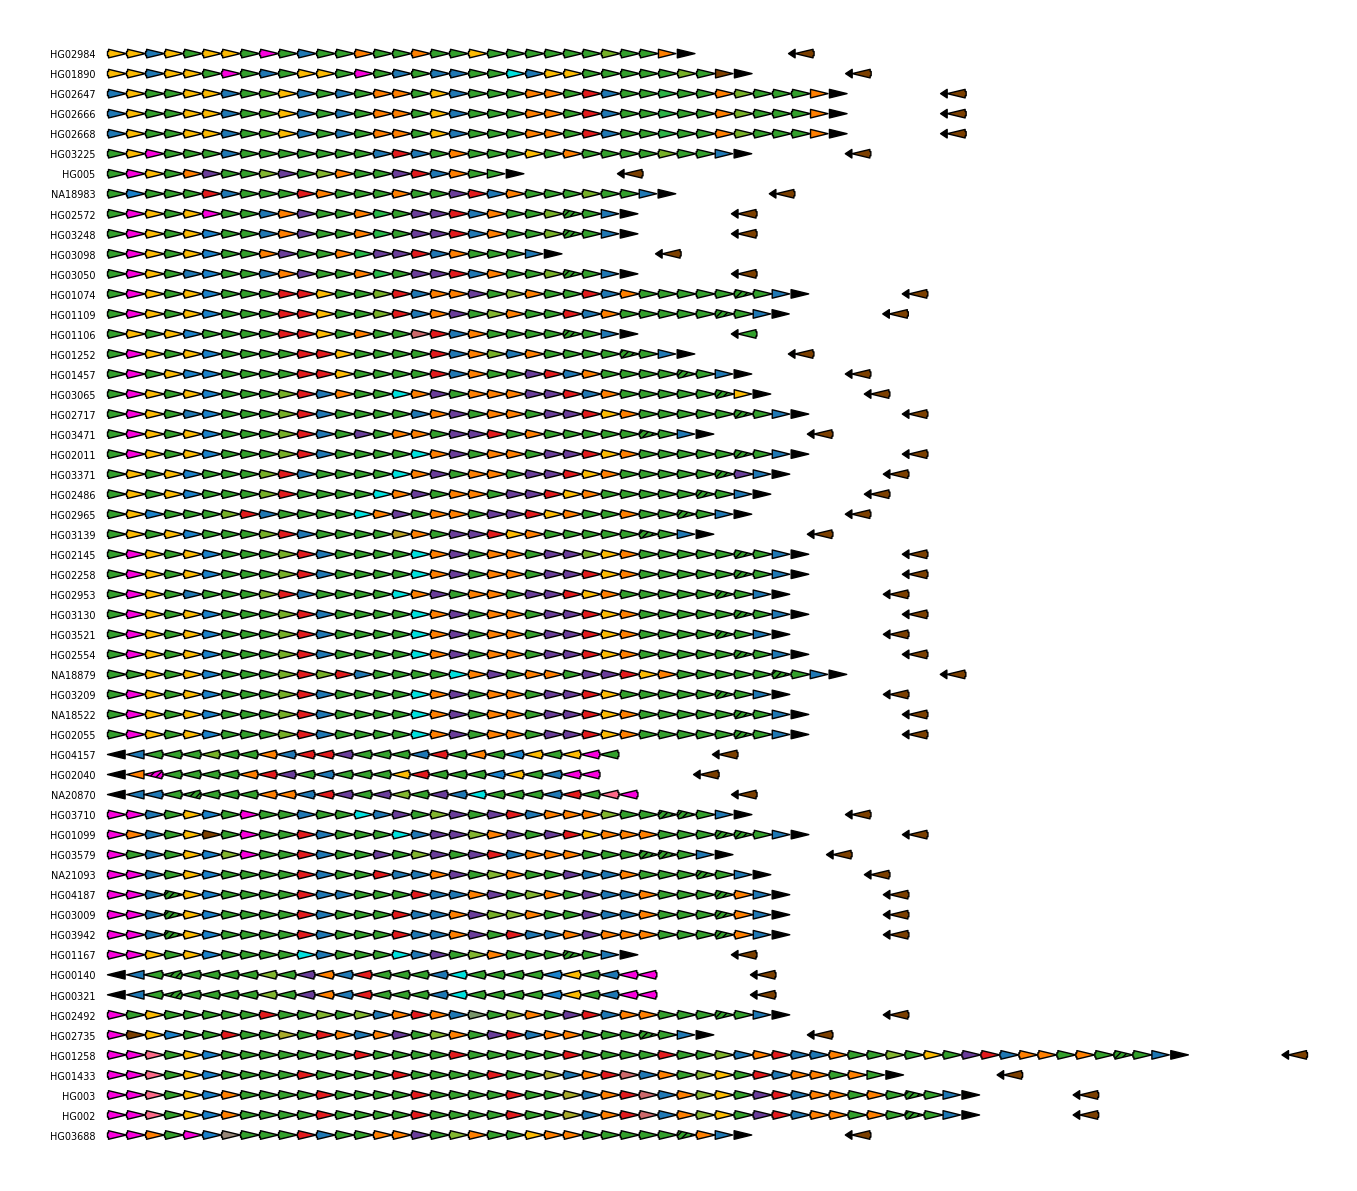

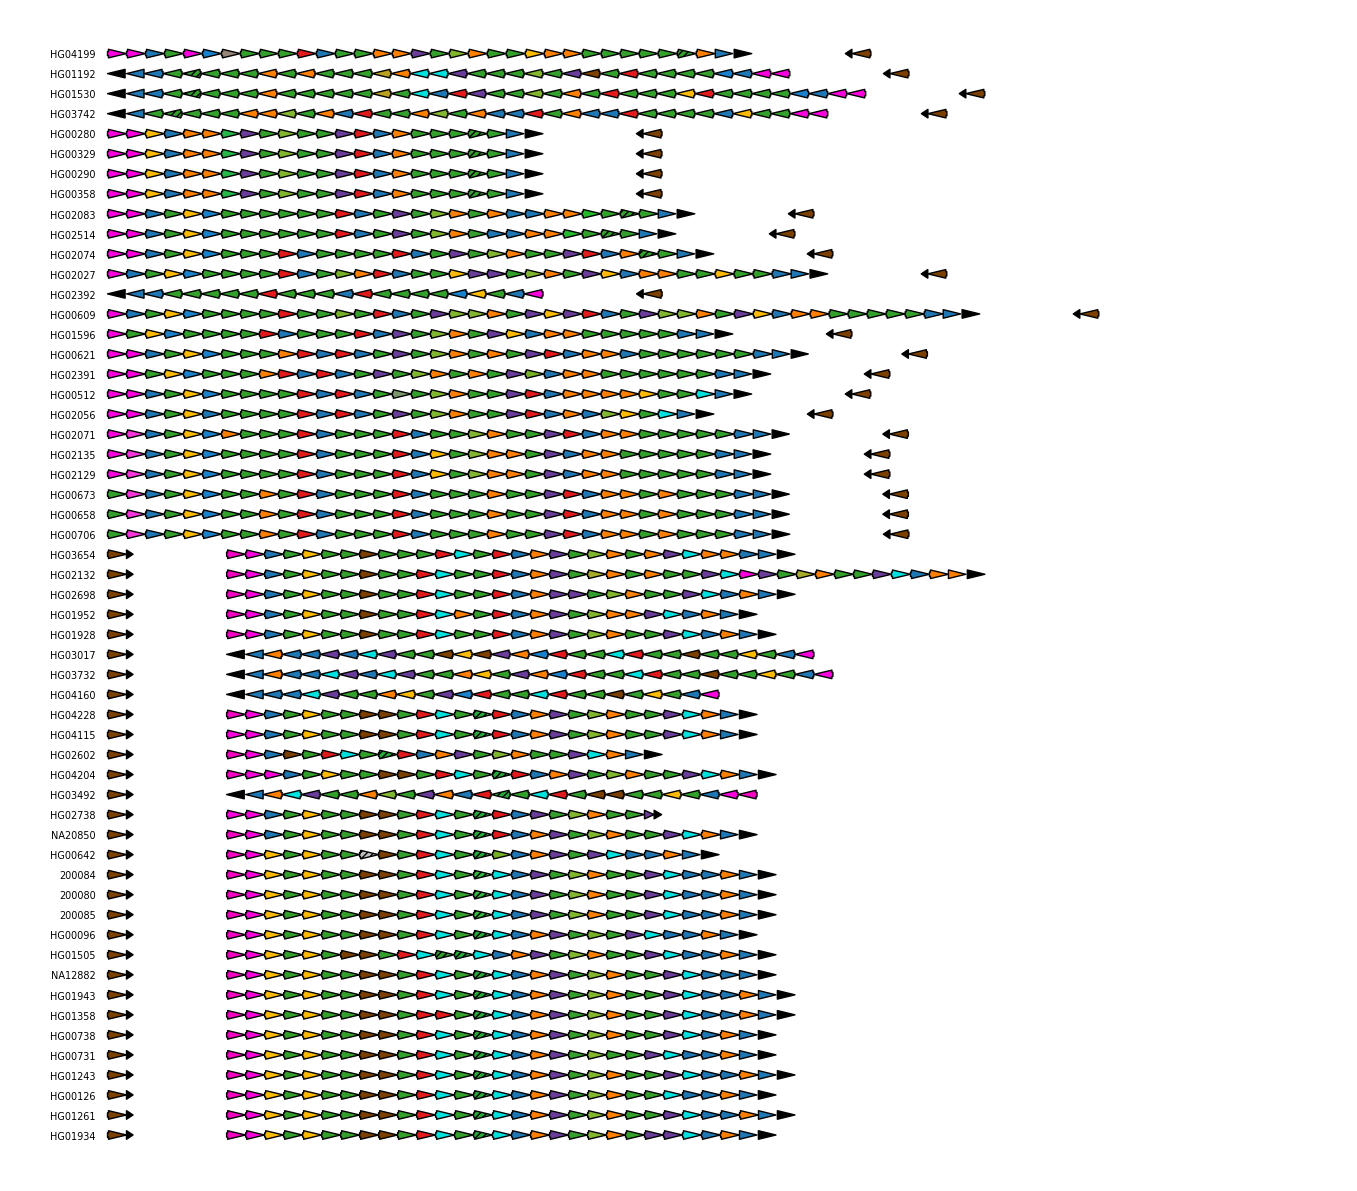

In [47]:
import math
from pygenomeviz import GenomeViz

def chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

dbgapssamples = {'NA12883','NA12884'}
plot_order = [s for s in phylogeneticOrder if s not in dbgapssamples]

seen = set()
ordered_genomes = []
for sample in plot_order:
    for genome in by_sample.get(sample, []):
        gname = genome["name"]
        if gname in seen:
            continue
        seen.add(gname)
        ordered_genomes.append(genome)

global_size = max(int(g["size"]) + 1 for g in ordered_genomes) if ordered_genomes else 1
print("global_size:", global_size)

per_fig = math.ceil(len(ordered_genomes) / 2)

for page_idx, genome_chunk in enumerate(chunks(ordered_genomes, per_fig), start=1):
    gv = GenomeViz(fig_width=12, fig_track_height=0.1, feature_track_ratio=0.75)
    gname2realsize = {}

    for genome in genome_chunk:
        gname = genome["name"]
        real_size = int(genome["size"]) + 1
        gname2realsize[gname] = real_size
        features = genome["features"]

        track = gv.add_feature_track(
            gname,
            global_size,
            labelsize=7,
            label_kws={"color": "black"},
            line_kws={"lw": 0, "alpha": 0}, 
        )

        for feature in features:
            start, end, strand, geneName, contig, realStart, realEnd = feature
            start = int(start); end = int(end)
            realStart = int(realStart); realEnd = int(realEnd)

            coordinateColorings2 = {
                k: v for k, v in (coordinateColorings or {}).items() if contig in k
            } if 'coordinateColorings' in globals() else {}

            trueColor = None
            hatchFlag = None
            for key, colorsListTemp in coordinateColorings2.items():
                try:
                    s2, e2 = map(int, key.split(":")[1].split("-"))
                except Exception:
                    continue
                overlap = max(0, min(realEnd, e2) - max(realStart, s2))
                if overlap > 100:
                    trueColor = colorsListTemp[0]
                    hatchFlag = colorsListTemp[1]
                    break

            fc = trueColor if trueColor else "black"
            hatch = "/////" if hatchFlag == "black" else None
            strand_dir = 1 if strand == "+" else -1

            track.add_feature(
                start, end, strand_dir,
                plotstyle="bigarrow",
                facecolor=fc,
                hatch=hatch,
                lw=1,
                ec="black",
            )

    fig = gv.plotfig()

    for ax in fig.axes:
        if ax.has_data():
            ax.set_xlim(0, global_size)

    for ax in fig.axes:
        label = ax.get_ylabel()
        if label in gname2realsize:
            real_size = gname2realsize[label]
            y0, y1 = ax.get_ylim()
            ymid = (y0 + y1) / 2.0  
            ax.hlines(
                y=ymid, xmin=0, xmax=real_size,
                colors="black", linewidth=0.8, zorder=0
            )

    out = f"/TSPY_page{page_idx}_Jan202026.pdf"
    out2 = f"/TSPY_page{page_idx}_Jan202026.jpg"
    fig.savefig(out)
    fig.savefig(out2, dpi=300)
    print("Saved", out)
